In [9]:
import numpy as np
import pandas as pd
import os
import sys
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as models
import time
import matplotlib.pyplot as plt
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from pathlib import Path
from PIL import Image
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load DataSet

https://github.com/VisDrone/VisDrone-Dataset

In [ ]:
def visdrone2yolo(dir: Path):
    def convert(size, box):
        dw = 1. / size[0]
        dh = 1. / size[1]
        return (box[0]+box[2]/2)*dw, (box[1]+box[3]/2)*dh, box[2]*dw, box[3]*dh

    label_dir = dir / "labels"
    label_dir.mkdir(exist_ok=True)

    for txt in tqdm((dir / "annotations").glob("*.txt")):
        img_path = dir / "images" / txt.name.replace('.txt', '.jpg')
        if not img_path.exists():
            continue
        w, h = Image.open(img_path).size
        yolo_lines = []
        with open(txt) as f:
            for line in f:
                parts = line.strip().split(',')
                if parts[4] == '0':  # ignored regions 제외
                    continue
                cls_id = int(parts[5]) - 1  # VisDrone 1~10 → YOLO 0~9
                box = list(map(int, parts[:4]))
                x, y, w_box, h_box = convert((w, h), box)
                yolo_lines.append(f"{cls_id} {x:.6f} {y:.6f} {w_box:.6f} {h_box:.6f}\n")
        out_file = str(txt).replace("annotations", "labels")
        with open(out_file, "w") as f:
            f.writelines(yolo_lines)


In [ ]:
# 실제 데이터셋 경로에 대해 실행
visdrone2yolo(Path("/home/elicer/jhl/VisDrone-DET/train"))
visdrone2yolo(Path("/home/elicer/jhl/VisDrone-DET/val"))
visdrone2yolo(Path("/home/elicer/jhl/VisDrone-DET/test-dev"))

In [ ]:
# VisDrone 라벨 폴더 경로
label_dirs = [
    Path("/home/elicer/jhl/VisDrone-DET/train"),
    Path("/home/elicer/jhl/VisDrone-DET/val"),
    Path("/home/elicer/jhl/VisDrone-DET/test-dev"),
]

def person_vs_nonperson(label_dir: Path):
    if not label_dir.exists():
        print(f"[건너뜀] {label_dir} (폴더 없음)")
        return

    for txt in tqdm(label_dir.glob("*.txt"), desc=label_dir.name):
        out_lines = []
        with open(txt, "r") as f:
            for ln in f:
                parts = ln.strip().split()
                if not parts:
                    continue

                # 원본 YOLO class: 0=pedestrian, 1=people, 2~9=기타
                cls = parts[0]
                if cls in ("0", "1"):
                    parts[0] = "0"          # person
                else:
                    parts[0] = "1"          # non-person
                out_lines.append(" ".join(parts) + "\n")

        with open(txt, "w") as f:
            f.writelines(out_lines)

for d in label_dirs:
    person_vs_nonperson(d)
print("✅ 0(person) / 1(non-person) 변환 완료")

## Resnet DataSet

### Resnet v1용 Dataset 생성

YOLO 추론 결과를 기반으로 데이터셋을 생성

In [ ]:
import os
import cv2
import torch
from tqdm import tqdm

# YOLO 모델 로드
yolo = torch.hub.load('ultralytics/yolov5', 'custom', path='/home/elicer/jhl/visdrone_yolo/exp2/weights/best.pt')
yolo.conf = 0.1  # confidence threshold

# VisDrone split 디렉토리들
splits = ['train', 'val', 'test-dev']
base_dir = '/home/elicer/jhl/VisDrone-DET'

# 저장 루트
save_root = '/home/elicer/jhl/_dataset'
os.makedirs(f'{save_root}/person', exist_ok=True)
os.makedirs(f'{save_root}/non_person', exist_ok=True)

for split in splits:
    img_dir = os.path.join(base_dir, split, 'images')
    image_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
    
    print(f"[{split}] 총 {len(image_files)}장 처리 중...")

    for fname in tqdm(image_files):
        img_path = os.path.join(img_dir, fname)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # YOLO 추론
        results = yolo(img)
        boxes = results.xyxy[0]  # [x1, y1, x2, y2, conf, cls]

        for i, box in enumerate(boxes):
            x1, y1, x2, y2, conf, cls = box
            cls = int(cls.item())
            label = 'person' if cls == 0 else 'non_person'

            crop = img[int(y1):int(y2), int(x1):int(x2)]
            if crop.size == 0:  # 유효하지 않은 bbox는 건너뜀
                continue

            save_path = os.path.join(save_root, label, f'{split}_{fname[:-4]}_{i}.jpg')
            cv2.imwrite(save_path, crop)

### Resnet v2용 Dataset 생성

1) GT라벨을 기반으로 데이터셋 생성

In [ ]:
import os
import cv2

# VisDrone-DET의 루트 디렉토리 (절대 경로)
base_dir = '/home/elicer/jhl/VisDrone-DET'

# ResNet용 저장 루트 (절대 경로)
save_root = '/home/elicer/jhl/resnet_dataset_new'
person_dir = os.path.join(save_root, 'person')
non_person_dir = os.path.join(save_root, 'non_person')

# 저장 폴더 생성
os.makedirs(person_dir, exist_ok=True)
os.makedirs(non_person_dir, exist_ok=True)

# 처리할 split들 (test-dev 일단 제외)
splits = ['train', 'val']

# Person으로 간주할 VisDrone 카테고리
PERSON_CATEGORIES = {1, 2}

for split in splits:
    img_dir = os.path.join(base_dir, split, 'images')
    ann_dir = os.path.join(base_dir, split, 'annotations')

    if not os.path.isdir(img_dir) or not os.path.isdir(ann_dir):
        print(f"[Warning] {split} 디렉토리에 images 또는 annotations 폴더가 없습니다.")
        continue

    image_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
    print(f"[{split}] 총 {len(image_files)}장 처리 중...")

    for fname in image_files:
        img_path = os.path.join(img_dir, fname)
        # 어노테이션 파일명은 이미지 파일명(.jpg→.txt)과 동일
        ann_fname = fname.replace('.jpg', '.txt')
        ann_path = os.path.join(ann_dir, ann_fname)

        # 이미지 읽기
        img = cv2.imread(img_path)
        if img is None:
            print(f"[Warning] 이미지 로드 실패: {img_path}")
            continue
        h, w, _ = img.shape

        # 어노테이션 파일이 없으면 건너뜀
        if not os.path.isfile(ann_path):
            continue

        with open(ann_path, 'r') as f:
            lines = f.read().strip().splitlines()

        for idx, line in enumerate(lines):
            # VisDrone 어노테이션은 CSV 형식 (콤마로 구분)
            parts = line.strip().split(',')
            if len(parts) < 6:
                continue

            # bbox 좌표 및 크기
            x_left  = int(float(parts[0]))
            y_top   = int(float(parts[1]))
            box_w   = int(float(parts[2]))
            box_h   = int(float(parts[3]))
            category = int(parts[5])

            # 좌표가 이미지 경계를 넘지 않도록 클램프
            x1 = max(0, x_left)
            y1 = max(0, y_top)
            x2 = min(w, x_left + box_w)
            y2 = min(h, y_top + box_h)

            # 잘린 영역이 유효한지 확인
            if x2 <= x1 or y2 <= y1:
                continue

            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            # 카테고리에 따라 저장 경로 결정
            if category in PERSON_CATEGORIES:
                label_dir = person_dir
            else:
                label_dir = non_person_dir

            # 저장 파일명: split_imageName_index.jpg
            save_fname = f"{split}_{fname[:-4]}_{idx}.jpg"
            save_path = os.path.join(label_dir, save_fname)

            # JPG 품질 기본값으로 저장
            cv2.imwrite(save_path, crop)

    print(f"[{split}] 저장 완료: '{person_dir}' 및 '{non_person_dir}'")

2) Dataset에 R-ESRGAN x4 적용

In [ ]:
import os
import cv2
from tqdm import tqdm

# ──────────────────────────────────────────────────────────────────────────────
# Real-ESRGAN / BasicSR 임포트 (pip으로 설치된 경우)
# ──────────────────────────────────────────────────────────────────────────────
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

# ──────────────────────────────────────────────────────────────────────────────
# 1. R-ESRGAN 모델 로드 (절대 경로 사용)
# ──────────────────────────────────────────────────────────────────────────────
sr_model = RealESRGANer(
    scale=4,
    model_path='/home/elicer/Real-ESRGAN/weights/RealESRGAN_x4plus.pth',
    model=RRDBNet(
        num_in_ch=3,
        num_out_ch=3,
        num_feat=64,
        num_block=23,
        num_grow_ch=32
    ),
    tile=0,
    tile_pad=10,
    pre_pad=0,
    half=False
)

# ──────────────────────────────────────────────────────────────────────────────
# 2. 원본(person/non_person) 및 SR 결과 저장 경로 설정 (절대 경로)
# ──────────────────────────────────────────────────────────────────────────────
src_root = '/home/elicer/jhl/resnet_dataset_new'       # 원본 디렉터리
dst_root = '/home/elicer/jhl/resnet_dataset_new_sr'    # SR 적용 결과를 저장할 루트

# ──────────────────────────────────────────────────────────────────────────────
# 3. 목표 디렉토리(person, non_person) 생성
# ──────────────────────────────────────────────────────────────────────────────
person_dst     = os.path.join(dst_root, 'person')
non_person_dst = os.path.join(dst_root, 'non_person')
os.makedirs(person_dst,     exist_ok=True)
os.makedirs(non_person_dst, exist_ok=True)

# ──────────────────────────────────────────────────────────────────────────────
# 4. src_root 내의 두 폴더(person, non_person) 순회하며 SR 적용 + 진행 바 출력
# ──────────────────────────────────────────────────────────────────────────────
classes = ['person', 'non_person']

for cls in classes:
    src_dir = os.path.join(src_root, cls)
    if not os.path.isdir(src_dir):
        print(f"[Warning] 원본 디렉터리를 찾을 수 없습니다: {src_dir}")
        continue

    image_files = [
        f for f in os.listdir(src_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    total_images = len(image_files)
    print(f"\n[{cls}] 총 {total_images}장 처리 중...")

    # tqdm을 사용하여 진행 상황 표시
    for fname in tqdm(image_files, desc=f"{cls} 처리", unit="image"):
        src_path = os.path.join(src_dir, fname)

        # (1) 이미지 로드
        img = cv2.imread(src_path, cv2.IMREAD_COLOR)
        if img is None:
            tqdm.write(f"[Warning] 이미지 로드 실패: {src_path}")
            continue

        # (3.1) 기존에 SR 결과가 이미 저장되어 있는지 확인
        #      저장 경로 결정: dst_root/<cls>/
        if cls == 'person':
            dst_dir = person_dst
        else:
            dst_dir = non_person_dst

        dst_path = os.path.join(dst_dir, fname)
        if os.path.exists(dst_path):
            # 이미 SR 이미지가 있으면 스킵
            # tqdm 쓰면 진행 표시를 방해하지 않으면서 메시지 출력 가능
            #tqdm.write(f"[Skip] 이미 처리된 파일: {dst_path}")
            continue

        # (2) R-ESRGAN으로 업스케일링 (outscale=4)
        try:
            sr_img, _ = sr_model.enhance(img, outscale=4)
        except Exception as e:
            tqdm.write(f"[Error] SR 적용 중 예외 발생: {src_path} → {e}")
            continue

        # (3.2) SR 결과 저장
        cv2.imwrite(dst_path, sr_img)

    print(f"[{cls}] SR 적용 및 저장 완료: '{dst_root}/{cls}'")

print(
    f"\n모든 이미지의 SR 적용 완료! 결과는 아래 두 폴더에 저장되었습니다:\n"
    f"  - {person_dst}\n"
    f"  - {non_person_dst}"
)

# YOLOv5 설치

In [ ]:
# 1. 작업 디렉토리 설정
import os
os.makedirs('/home/elicer', exist_ok=True)
os.chdir('/home/elicer')

# 2. YOLOv5 저장소 클론
!git clone https://github.com/ultralytics/yolov5 yolov5_1

# 3. YOLOv5 디렉토리로 이동
%cd /home/elicer/yolov5_1

# 4. 의존성 설치
!pip install -r requirements.txt

# Real-ESRGAN 설치

In [ ]:
!pip uninstall -y numpy #numpy 버전 맞추기 용

%cd /home/elicer

#R-ESRGAN 저장소 클론
!git clone https://github.com/xinntao/Real-ESRGAN.git
%cd Real-ESRGAN

#의존성 설치
!pip install -r requirements.txt
!python setup.py develop

#가중치 다운로드
!wget https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth -P weights

# Training

## only YOLO training

In [ ]:
%cd /home/elicer/jhl/yolov5/
!python train.py --img 768 --batch-size 48 --epochs 50 --data /home/elicer/jhl/VisDrone.yaml --weights yolov5s.pt --name exp --project /home/elicer/jhl/visdrone_yolo

## Real-ESRGAN

Real-ESRGAN은 pre-trained된 가중치를 사용했다.

## Resnet classifier training

### Resnet ver1

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

# 절대 경로 설정
DATA_DIR = '/home/elicer/jhl/resnet_dataset'
MODEL_SAVE_PATH = '/home/elicer/jhl/resnet_classifier.pt'

# 전처리 및 데이터로더
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=8, pin_memory=True)

# 모델 정의
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)  # person / non-person

# 학습 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler()  # AMP

# 학습 루프
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)
    for images, labels in loop:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # tqdm bar에 현재 배치 정확도 표시
        loop.set_postfix(loss=loss.item(), acc=correct / total)

    # 에폭 결과 출력
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f'Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}', flush=True)

# 모델 저장
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}", flush=True)

### Resnet ver2

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

# 절대 경로 설정
DATA_DIR = '/home/elicer/jhl/resnet_dataset_new_sr'
MODEL_SAVE_PATH = '/home/elicer/jhl/resnet_new_sr_classifier.pt'

# 전처리 및 데이터로더
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=8, pin_memory=True)

# 모델 정의
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)  # person / non-person

# 학습 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler()  # AMP

# 학습 루프
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)
    for images, labels in loop:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # tqdm bar에 현재 배치 정확도 표시
        loop.set_postfix(loss=loss.item(), acc=correct / total)

    # 에폭 결과 출력
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f'Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}', flush=True)

# 모델 저장
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}", flush=True)

# Inference

## GT

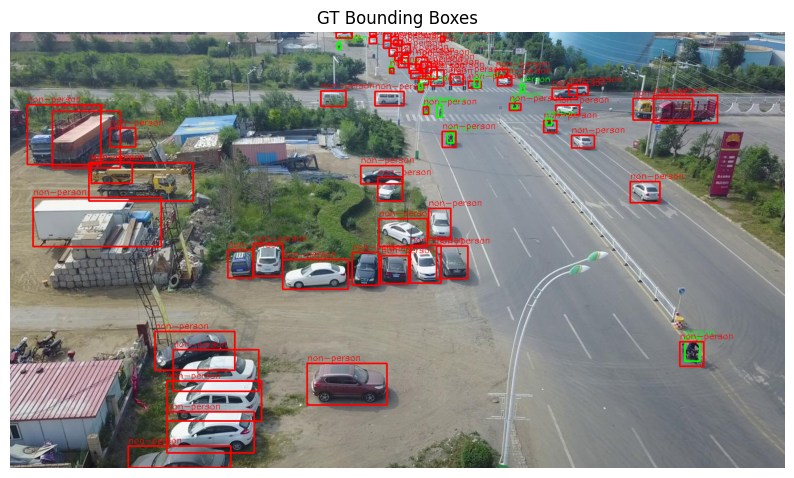

In [3]:
# 파일 경로
# '/home/elicer/jhl/VisDrone-DET/test-dev/images/0000011_01350_d_0000003.jpg'
img_path = Path('/home/elicer/jhl/VisDrone-DET/test-dev/images/0000006_00611_d_0000002.jpg')
label_path = Path('/home/elicer/jhl/VisDrone-DET/test-dev/labels/0000006_00611_d_0000002.txt')

# 클래스 이름
class_names = {0: 'person', 1: 'non-person'}

# 이미지 로드
img = cv2.imread(str(img_path))
H, W = img.shape[:2]

# 라벨 읽고 박스 그리기
with open(label_path, 'r') as f:
    for line in f:
        cls, cx, cy, w, h = map(float, line.strip().split())
        x1 = int((cx - w / 2) * W)
        y1 = int((cy - h / 2) * H)
        x2 = int((cx + w / 2) * W)
        y2 = int((cy + h / 2) * H)
        label = class_names.get(int(cls), f"class {int(cls)}")
        color = (0, 255, 0) if int(cls) == 0 else (0, 0, 255)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# BGR → RGB 변환 후 시각화
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title("GT Bounding Boxes")
plt.axis('off')
plt.show()

## only YOLO

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /home/elicer/.cache/torch/hub/master.zip
YOLOv5 🚀 2025-6-5 Python-3.10.15 torch-2.0.1+cu117 CUDA:0 (NVIDIA A100 80GB PCIe MIG 2g.20gb, 19968MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
image 1/1: 765x1360 11 persons, 66 non-persons
Speed: 3.3ms pre-process, 42.9ms inference, 2.7ms NMS per image at shape (1, 3, 384, 640)


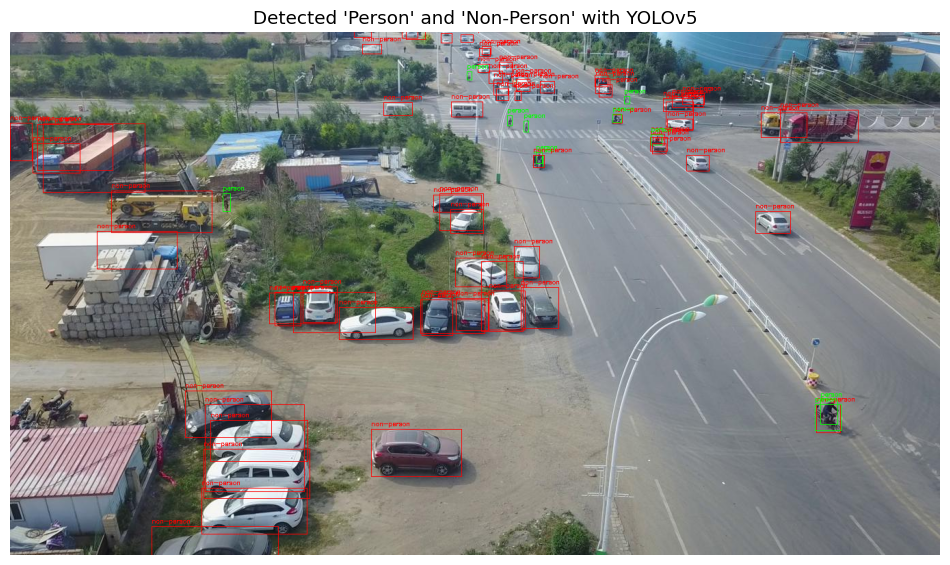

In [4]:
class_names = {0: 'person', 1: 'non-person'}

# YOLOv5 모델 로드
yolo_model = torch.hub.load('ultralytics/yolov5', 'custom', 
                            path='/home/elicer/jhl/visdrone_yolo/exp2/weights/best.pt', 
                            force_reload=True)
yolo_model.conf = 0.15

# 이미지 경로

# 이미지 로드
input_img = cv2.imread(img_path)
input_pil = Image.fromarray(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))

# YOLO 추론
results = yolo_model(input_pil)
results.print()

%matplotlib inline

# 결과 추출
boxes = results.xyxy[0][:, :4].cpu().numpy()
confs = results.xyxy[0][:, 4].cpu().numpy()
classes = results.xyxy[0][:, 5].cpu().numpy()

# 시각화
vis_img = input_img.copy()
for box, cls, conf in zip(boxes, classes, confs):
    x1, y1, x2, y2 = map(int, box)
    cls = int(cls)
    label = f"{class_names.get(cls, 'unknown')}"
    color = (0, 255, 0) if cls == 0 else (0, 0, 255)  # 0: 파랑, 1: 빨강

    cv2.rectangle(vis_img, (x1, y1), (x2, y2), color, 1)
    cv2.putText(vis_img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX,
                0.3, color, 1)

# 출력
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.title("Detected 'Person' and 'Non-Person' with YOLOv5")
plt.axis('off')
plt.show()

## SR -> YOLO

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /home/elicer/.cache/torch/hub/master.zip
YOLOv5 🚀 2025-6-5 Python-3.10.15 torch-2.0.1+cu117 CUDA:0 (NVIDIA A100 80GB PCIe MIG 2g.20gb, 19968MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


	Tile 1/66
	Tile 2/66
	Tile 3/66
	Tile 4/66
	Tile 5/66
	Tile 6/66
	Tile 7/66
	Tile 8/66
	Tile 9/66
	Tile 10/66
	Tile 11/66
	Tile 12/66
	Tile 13/66
	Tile 14/66
	Tile 15/66
	Tile 16/66
	Tile 17/66
	Tile 18/66
	Tile 19/66
	Tile 20/66
	Tile 21/66
	Tile 22/66
	Tile 23/66
	Tile 24/66
	Tile 25/66
	Tile 26/66
	Tile 27/66
	Tile 28/66
	Tile 29/66
	Tile 30/66
	Tile 31/66
	Tile 32/66
	Tile 33/66
	Tile 34/66
	Tile 35/66
	Tile 36/66
	Tile 37/66
	Tile 38/66
	Tile 39/66
	Tile 40/66
	Tile 41/66
	Tile 42/66
	Tile 43/66
	Tile 44/66
	Tile 45/66
	Tile 46/66
	Tile 47/66
	Tile 48/66
	Tile 49/66
	Tile 50/66
	Tile 51/66
	Tile 52/66
	Tile 53/66
	Tile 54/66
	Tile 55/66
	Tile 56/66
	Tile 57/66
	Tile 58/66
	Tile 59/66
	Tile 60/66
	Tile 61/66
	Tile 62/66
	Tile 63/66
	Tile 64/66
	Tile 65/66
	Tile 66/66


image 1/1: 3060x5440 9 persons, 61 non-persons
Speed: 82.1ms pre-process, 1909.1ms inference, 1.4ms NMS per image at shape (1, 3, 384, 640)


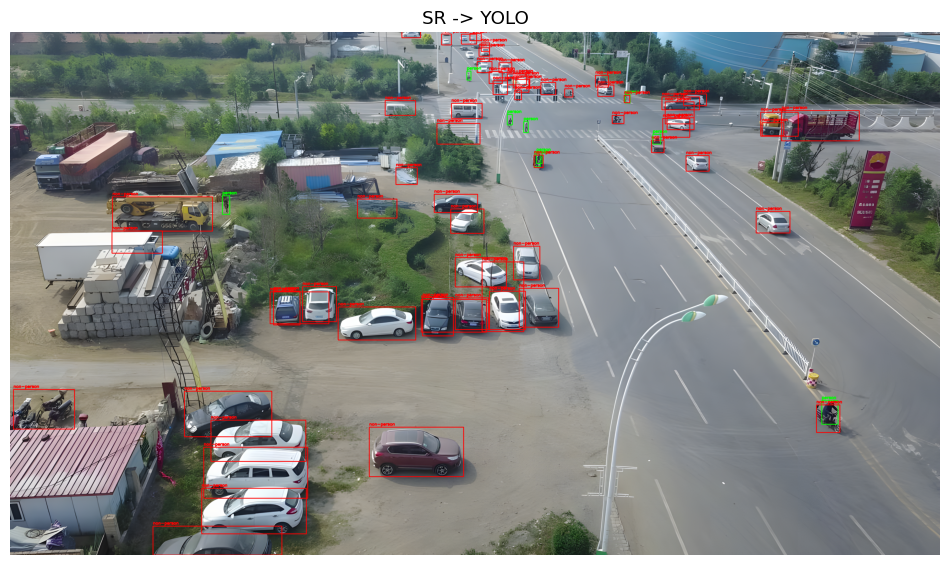

In [5]:
# R-ESRGAN 모델 로드
def load_realesrgan_model():
    model = RealESRGANer(
        scale=4,
        model_path='/home/elicer/Real-ESRGAN/weights/RealESRGAN_x4plus.pth',
        model = RRDBNet(
            num_in_ch=3,
            num_out_ch=3,
            num_feat=64,
            num_block=23,
            num_grow_ch=32,
            scale=4
        ),
        tile=128, tile_pad=10, pre_pad=0, half=False
    )
    return model

# Super Resolution 함수 정의
def apply_super_resolution_realesrgan(image: np.ndarray, sr_model) -> np.ndarray:
    sr_image, _ = sr_model.enhance(image, outscale=4)
    return sr_image

    
%matplotlib inline
# YOLOv5 모델 로드 (exp14 - best.pt 로드)
yolo_model = torch.hub.load('ultralytics/yolov5', 'custom', path='/home/elicer/jhl/visdrone_yolo/exp2/weights/best.pt', force_reload=True)
yolo_model.conf = 0.15

# 입력 이미지 로드
img_path = Path('/home/elicer/jhl/VisDrone-DET/test-dev/images/0000006_00611_d_0000002.jpg')
input_img = cv2.imread(img_path)

# R-ESRGAN 적용
sr_model = load_realesrgan_model()
sr_img = apply_super_resolution_realesrgan(input_img, sr_model)

# YOLO 추론
sr_pil = Image.fromarray(cv2.cvtColor(sr_img, cv2.COLOR_BGR2RGB))
results = yolo_model(sr_pil)
results.print()

# Super Resolution 결과를 다시 BGR로 변환해서 YOLO 이미지랑 맞춰줌
sr_bgr = cv2.cvtColor(np.array(sr_pil), cv2.COLOR_RGB2BGR)

# 탐지된 결과를 순회하면서 bbox 그리기
for *xyxy, conf, cls in results.xyxy[0].tolist():
    x1, y1, x2, y2 = map(int, xyxy)
    cls = int(cls)
    label = f"{yolo_model.names[cls]}"

    # 클래스가 person이면 빨간색, 아니면 초록색
    if yolo_model.names[cls] == "person":
        color = (0, 255, 0)  # 빨간색 (BGR)
    else:
        color = (0, 0, 255)  # 초록색 (BGR)

    cv2.rectangle(sr_bgr, (x1, y1), (x2, y2), color=color, thickness=4)
    cv2.putText(sr_bgr, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 4)
# 시각화
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(sr_bgr, cv2.COLOR_BGR2RGB))
plt.title("SR -> YOLO")
plt.axis("off")
plt.show()

## YOLO -> SR -> ResNet

### ver1

In [ ]:
import os
import cv2
import torch
import gc
from PIL import Image
from torchvision import transforms, models
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet
from pathlib import Path
from tqdm import tqdm

# ──────────────────────────────────────────────────────────────────────────────
# 0. 디바이스 설정
# ──────────────────────────────────────────────────────────────────────────────
use_cuda = torch.cuda.is_available()
device_index = '0' if use_cuda else 'cpu'
device = torch.device(f'cuda:{device_index}' if use_cuda else 'cpu')

print(f"Torch CUDA available? {use_cuda}")
if use_cuda:
    print("GPU device count:", torch.cuda.device_count())
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA 사용 불가, CPU 모드로 동작합니다.")
print(f"=== 최종 디바이스: {device} ===\n")

# ──────────────────────────────────────────────────────────────────────────────
# 1. YOLOv5 모델 로드 (GPU 모드)
# ──────────────────────────────────────────────────────────────────────────────
yolo = torch.hub.load(
    'ultralytics/yolov5',
    'custom',
    path='/home/elicer/jhl/visdrone_yolo/exp2/weights/best.pt',
    device=device_index,
    force_reload=False
)
yolo.conf = 0.2  # confidence threshold

# ──────────────────────────────────────────────────────────────────────────────
# 2. R-ESRGAN 모델 로드 (GPU 모드, OOM 방지를 위해 tile=200 적용 예시)
# ──────────────────────────────────────────────────────────────────────────────
sr_model = RealESRGANer(
    scale=4,
    model_path='/home/elicer/Real-ESRGAN/weights/RealESRGAN_x4plus.pth',
    model=RRDBNet(num_in_ch=3, num_out_ch=3,
                  num_feat=64, num_block=23, num_grow_ch=32),
    tile_pad=10,
    pre_pad=0,
    half=False,
    device=device
)

# ──────────────────────────────────────────────────────────────────────────────
# 3. ResNet 분류기 로드 (GPU 모드)
# ──────────────────────────────────────────────────────────────────────────────
resnet = models.resnet18(pretrained=False)
resnet.fc = torch.nn.Linear(resnet.fc.in_features, 2)
resnet.load_state_dict(torch.load(
    '/home/elicer/jhl/resnet_classifier.pt',
    map_location=device
))
resnet = resnet.to(device)
resnet.eval()

# ──────────────────────────────────────────────────────────────────────────────
# 4. 전처리 transform 정의 (ResNet 입력용)
# ──────────────────────────────────────────────────────────────────────────────
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ──────────────────────────────────────────────────────────────────────────────
# 5. 결과 저장 디렉토리 설정 (원래 경로 유지)
# ──────────────────────────────────────────────────────────────────────────────
OUT_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/inference_BBOX_SR_Resnet_v1")
TXT_DIR = OUT_DIR / "txt"
IMG_DIR = OUT_DIR / "vis"
TXT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

# ──────────────────────────────────────────────────────────────────────────────
# 6. 파이프라인 함수 정의
#    - .txt가 이미 있으면 스킵
#    - 하나라도 SR 실패가 발생하면 해당 이미지 전체를 스킵 (저장하지 않음)
# ──────────────────────────────────────────────────────────────────────────────
def pipeline_save(image_path):
    image_path = Path(image_path)

    # 1) 이미 .txt 결과가 있으면 스킵
    txt_path = TXT_DIR / f"{image_path.stem}.txt"
    if txt_path.exists() and txt_path.stat().st_size > 0:
        return

    orig = cv2.imread(str(image_path))
    if orig is None:
        print(f"[!] 이미지 로드 실패: {image_path}")
        return

    H, W = orig.shape[:2]
    records = []  
    sr_failed = False  # SR 실패 플래그

    # 2) YOLO 추론
    results = yolo(orig)
    boxes = results.xyxy[0]  # [N x 6]: x1, y1, x2, y2, conf, cls_idx

    for box in boxes:
        x1, y1, x2, y2, conf, cls_idx = box.tolist()
        x1_i, y1_i, x2_i, y2_i = float(x1), float(y1), float(x2), float(y2)

        # 좌표 유효성 검사
        if x2_i <= x1_i or y2_i <= y1_i:
            continue

        crop = orig[int(y1_i):int(y2_i), int(x1_i):int(x2_i)]
        if crop.size == 0:
            continue

        # 3) R-ESRGAN 업스케일
        try:
            upscaled, _ = sr_model.enhance(crop, outscale=4)
        except Exception as e:
            # SR에 실패했으면 전체 이미지 스킵
            sr_failed = True
            break

        # 4) ResNet 분류
        img_pil = Image.fromarray(cv2.cvtColor(upscaled, cv2.COLOR_BGR2RGB))
        input_tensor = preprocess(img_pil).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = resnet(input_tensor)
            pred = torch.argmax(logits, dim=1).item()
            # ResNet: 1=person, 0=non-person
            label_idx = 1 if pred == 0 else 0

        # 5) 기록용 리스트에 추가
        records.append((label_idx, x1_i, y1_i, x2_i, y2_i, conf))

    # 6) 하나라도 SR 실패했으면, 기록 없이 바로 끝냄 (나중에 감지)
    if sr_failed or not records:
        del orig, boxes, results
        torch.cuda.empty_cache()
        gc.collect()
        return

    # 7) 실제로 .txt 파일에 기록
    with open(txt_path, "w") as f_txt:
        for label_idx, x1_i, y1_i, x2_i, y2_i, conf in records:
            f_txt.write(f"{label_idx} {x1_i:.2f} {y1_i:.2f} {x2_i:.2f} {y2_i:.2f} {conf:.4f}\n")

    # 8) 메모리 정리
    del orig, boxes, results
    torch.cuda.empty_cache()
    gc.collect()

# ──────────────────────────────────────────────────────────────────────────────
# 7. 메인 루프: 폴더 내 이미지 절반 처리
# ──────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    all_imgs = list(Path("/home/elicer/jhl/VisDrone-DET/test-dev/images").glob("*.jpg"))
    img_paths = all_imgs[: len(all_imgs) // 2 ]  # 절반만 처리

    print(f"총 {len(img_paths)}개의 이미지 처리 시작\n")
    for img_path in tqdm(img_paths, desc="절반 이미지 처리 중"):
        try:
            pipeline_save(img_path)
        except Exception as e:
            print(f"[ERROR] {img_path.name} 처리 중 예외: {e}")

    print(f"\n✅ 전체 저장 완료: {len(img_paths)}개 이미지 → {TXT_DIR}")

### ver2

In [ ]:
import os
import cv2
import torch
import gc
from PIL import Image
from torchvision import transforms, models
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet
from pathlib import Path
from tqdm import tqdm

# ──────────────────────────────────────────────────────────────────────────────
# 0. 디바이스 설정
# ──────────────────────────────────────────────────────────────────────────────
use_cuda = torch.cuda.is_available()
device_index = '0' if use_cuda else 'cpu'
device = torch.device(f'cuda:{device_index}' if use_cuda else 'cpu')

print(f"Torch CUDA available? {use_cuda}")
if use_cuda:
    print("GPU device count:", torch.cuda.device_count())
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA 사용 불가, CPU 모드로 동작합니다.")
print(f"=== 최종 디바이스: {device} ===\n")

# ──────────────────────────────────────────────────────────────────────────────
# 1. YOLOv5 모델 로드 (GPU 모드)
# ──────────────────────────────────────────────────────────────────────────────
yolo = torch.hub.load(
    'ultralytics/yolov5',
    'custom',
    path='/home/elicer/jhl/visdrone_yolo/exp2/weights/best.pt',
    device=device_index,
    force_reload=False
)
yolo.conf = 0.2  # confidence threshold

# ──────────────────────────────────────────────────────────────────────────────
# 2. R-ESRGAN 모델 로드 (GPU 모드, OOM 방지를 위해 tile=200 적용 예시)
# ──────────────────────────────────────────────────────────────────────────────
sr_model = RealESRGANer(
    scale=4,
    model_path='/home/elicer/Real-ESRGAN/weights/RealESRGAN_x4plus.pth',
    model=RRDBNet(num_in_ch=3, num_out_ch=3,
                  num_feat=64, num_block=23, num_grow_ch=32),
    tile_pad=10,
    pre_pad=0,
    half=False,
    device=device
)

# ──────────────────────────────────────────────────────────────────────────────
# 3. ResNet 분류기 로드 (GPU 모드)
# ──────────────────────────────────────────────────────────────────────────────
resnet = models.resnet18(pretrained=False)
resnet.fc = torch.nn.Linear(resnet.fc.in_features, 2)
resnet.load_state_dict(torch.load(
    '/home/elicer/jhl/resnet_new_sr_classifier.pt',
    map_location=device
))
resnet = resnet.to(device)
resnet.eval()

# ──────────────────────────────────────────────────────────────────────────────
# 4. 전처리 transform 정의 (ResNet 입력용)
# ──────────────────────────────────────────────────────────────────────────────
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ──────────────────────────────────────────────────────────────────────────────
# 5. 결과 저장 디렉토리 설정 (원래 경로 유지)
# ──────────────────────────────────────────────────────────────────────────────
OUT_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/inference_BBOX_SR_Resnet")
TXT_DIR = OUT_DIR / "txt"
IMG_DIR = OUT_DIR / "vis"
TXT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

# ──────────────────────────────────────────────────────────────────────────────
# 6. 파이프라인 함수 정의
#    - .txt가 이미 있으면 스킵
#    - 하나라도 SR 실패가 발생하면 해당 이미지 전체를 스킵 (저장하지 않음)
# ──────────────────────────────────────────────────────────────────────────────
def pipeline_save(image_path):
    image_path = Path(image_path)

    # 1) 이미 .txt 결과가 있으면 스킵
    txt_path = TXT_DIR / f"{image_path.stem}.txt"
    if txt_path.exists() and txt_path.stat().st_size > 0:
        return

    orig = cv2.imread(str(image_path))
    if orig is None:
        print(f"[!] 이미지 로드 실패: {image_path}")
        return

    H, W = orig.shape[:2]
    records = []  
    sr_failed = False  # SR 실패 플래그

    # 2) YOLO 추론
    results = yolo(orig)
    boxes = results.xyxy[0]  # [N x 6]: x1, y1, x2, y2, conf, cls_idx

    for box in boxes:
        x1, y1, x2, y2, conf, cls_idx = box.tolist()
        x1_i, y1_i, x2_i, y2_i = float(x1), float(y1), float(x2), float(y2)

        # 좌표 유효성 검사
        if x2_i <= x1_i or y2_i <= y1_i:
            continue

        crop = orig[int(y1_i):int(y2_i), int(x1_i):int(x2_i)]
        if crop.size == 0:
            continue

        # 3) R-ESRGAN 업스케일
        try:
            upscaled, _ = sr_model.enhance(crop, outscale=4)
        except Exception as e:
            # SR에 실패했으면 전체 이미지 스킵
            sr_failed = True
            break

        # 4) ResNet 분류
        img_pil = Image.fromarray(cv2.cvtColor(upscaled, cv2.COLOR_BGR2RGB))
        input_tensor = preprocess(img_pil).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = resnet(input_tensor)
            pred = torch.argmax(logits, dim=1).item()
            # ResNet: 1=person, 0=non-person
            label_idx = 1 if pred == 0 else 0

        # 5) 기록용 리스트에 추가
        records.append((label_idx, x1_i, y1_i, x2_i, y2_i, conf))

    # 6) 하나라도 SR 실패했으면, 기록 없이 바로 끝냄 (나중에 감지)
    if sr_failed or not records:
        del orig, boxes, results
        torch.cuda.empty_cache()
        gc.collect()
        return

    # 7) 실제로 .txt 파일에 기록
    with open(txt_path, "w") as f_txt:
        for label_idx, x1_i, y1_i, x2_i, y2_i, conf in records:
            f_txt.write(f"{label_idx} {x1_i:.2f} {y1_i:.2f} {x2_i:.2f} {y2_i:.2f} {conf:.4f}\n")

    # 8) 메모리 정리
    del orig, boxes, results
    torch.cuda.empty_cache()
    gc.collect()

# ──────────────────────────────────────────────────────────────────────────────
# 7. 메인 루프: 폴더 내 이미지 절반 처리
# ──────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    all_imgs = list(Path("/home/elicer/jhl/VisDrone-DET/test-dev/images").glob("*.jpg"))
    img_paths = all_imgs[: len(all_imgs) // 2 ]  # 절반만 처리

    print(f"총 {len(img_paths)}개의 이미지 처리 시작\n")
    for img_path in tqdm(img_paths, desc="절반 이미지 처리 중"):
        try:
            pipeline_save(img_path)
        except Exception as e:
            print(f"[ERROR] {img_path.name} 처리 중 예외: {e}")

    print(f"\n✅ 전체 저장 완료: {len(img_paths)}개 이미지 → {TXT_DIR}")

### 결과 점검 (기대값 805와 다르면 추가 수행)

In [ ]:
from pathlib import Path

dir_path = Path("/home/elicer/jhl/VisDrone-DET/test-dev/inference_BBOX_SR_Resnet_v1/txt")
file_count = len(list(dir_path.glob("*")))
print(f"총 파일 수: {file_count}")

# Model Performance

## only YOLO

### 결과 저장

In [ ]:
# ==== 경로 설정 ====
IMG_DIR = Path('/home/elicer/jhl/VisDrone-DET/test-dev/images')
OUT_DIR = Path('/home/elicer/jhl/VisDrone-DET/test-dev/inference_yolo_only')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ==== YOLO 모델 로드 ====
class_names = {0: 'person', 1: 'non-person'}
yolo_model = torch.hub.load('ultralytics/yolov5', 'custom',
    path='/home/elicer/jhl/visdrone_yolo/exp2/weights/best.pt', force_reload=True)
yolo_model.conf = 0.15
yolo_model.eval()

# ==== YOLO Only Inference 후 저장 ====
img_paths = sorted(IMG_DIR.glob("*.jpg"))

for img_path in tqdm(img_paths, desc="YOLO-only Inference"):
    try:
        # 이미지 로드
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"[!] Failed to load image: {img_path}")
            continue

        # YOLO 추론
        pil_img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        results = yolo_model(pil_img)

        # 결과 저장
        out_path = OUT_DIR / f"{img_path.stem}.txt"
        with open(out_path, 'w') as f:
            for *xyxy, conf, cls in results.xyxy[0].tolist():
                x1, y1, x2, y2 = xyxy
                f.write(f"{int(cls)} {x1:.2f} {y1:.2f} {x2:.2f} {y2:.2f} {conf:.4f}\n")

        del pil_img, results
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"[ERROR] {img_path.name}: {e}")

print(f"\n✅ YOLO-only inference 완료: {len(img_paths)}개 결과 → {OUT_DIR}")

### perfomance 측정

In [6]:
## Threshold 설정

CONF_THRES = 0.15
IOU_THRES = 0.5

In [7]:
PRED_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/inference_yolo_only")
GT_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/labels")
IMG_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/images")

# IoU 계산 함수
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    box1Area = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    box2Area = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    unionArea = box1Area + box2Area - interArea
    return interArea / unionArea if unionArea > 0 else 0

# ===== 평가 대상: 앞 절반만 =====
pred_files = sorted(PRED_DIR.glob("*.txt"))
half_count = len(pred_files) // 2
pred_files = pred_files[:half_count]

gt_total = 0
scores = []
labels = []

for pred_file in tqdm(pred_files, desc="Evaluating first half"):
    gt_file = GT_DIR / pred_file.name
    img_file = IMG_DIR / f"{pred_file.stem}.jpg"

    if not gt_file.exists() or not img_file.exists():
        continue

    img = cv2.imread(str(img_file))
    H, W = img.shape[:2]

    # 예측 박스
    pred_boxes = []
    with open(pred_file, 'r') as f:
        for line in f:
            cls, x1, y1, x2, y2, conf = map(float, line.strip().split())
            if int(cls) != 0 or conf < CONF_THRES:
                continue
            x1 /= W; y1 /= H; x2 /= W; y2 /= H
            pred_boxes.append((conf, [x1, y1, x2, y2]))

    pred_boxes.sort(reverse=True)  # confidence 내림차순

    # 정답 박스
    gt_boxes = []
    with open(gt_file, 'r') as f:
        for line in f:
            cls, cx, cy, w, h = map(float, line.strip().split())
            if int(cls) != 0:
                continue
            x1 = cx - w / 2
            y1 = cy - h / 2
            x2 = cx + w / 2
            y2 = cy + h / 2
            gt_boxes.append([x1, y1, x2, y2])
    gt_total += len(gt_boxes)

    matched = set()
    for conf, pred_box in pred_boxes:
        found = False
        for i, gt_box in enumerate(gt_boxes):
            if i in matched:
                continue
            iou = compute_iou(pred_box, gt_box)
            if iou >= IOU_THRES:
                found = True
                matched.add(i)
                break
        if found:
            labels.append(1)
        else:
            labels.append(0)
        scores.append(conf)

# precision-recall curve를 이용한 AP 계산
from sklearn.metrics import precision_recall_curve, auc

scores = np.array(scores)
labels = np.array(labels)

precision_curve, recall_curve, _ = precision_recall_curve(labels, scores)
ap_50 = auc(recall_curve, precision_curve)

# 최종 지표
TP = np.sum((labels == 1))
FP = np.sum((labels == 0))
FN = gt_total - TP

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

print(f"\n📊 YOLO Evaluation (Person Class Only):")
print(f"TP: {TP}, FP: {FP}, FN: {FN}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"mAP@0.5:   {ap_50:.4f}")

Evaluating first half: 100%|██████████| 805/805 [00:07<00:00, 112.29it/s]



📊 YOLO Evaluation (Person Class Only):
TP: 4848, FP: 4971, FN: 15616
Precision: 0.4937
Recall:    0.2369
F1 Score:  0.3202
mAP@0.5:   0.8322


### time 측정

In [11]:
# ==== YOLO 모델 로드 ====
yolo_model = torch.hub.load('ultralytics/yolov5', 'custom',
    path='/home/elicer/jhl/visdrone_yolo/exp2/weights/best.pt', force_reload=True)
yolo_model.conf = 0.15
yolo_model.eval()

# ==== 이미지 로드 ====
img = cv2.imread(str(img_path))
if img is None:
    raise ValueError(f"[!] 이미지 로딩 실패: {img_path}")

pil_img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# ==== GPU 동기화 후 시간 측정 ====
torch.cuda.synchronize()
start_time = time.time()

results = yolo_model(pil_img)

torch.cuda.synchronize()
end_time = time.time()

elapsed = (end_time - start_time) * 1000  # ms 단위

# ==== 결과 출력 ====
print(f"\n✅ {img_path.name} 한 장 YOLO 추론 시간: {elapsed:.2f} ms")


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /home/elicer/.cache/torch/hub/master.zip
YOLOv5 🚀 2025-6-5 Python-3.10.15 torch-2.0.1+cu117 CUDA:0 (NVIDIA A100 80GB PCIe MIG 2g.20gb, 19968MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 



✅ 0000006_00159_d_0000001.jpg 한 장 YOLO 추론 시간: 12.21 ms


## SR -> YOLO

### 결과 저장

In [ ]:
# ==== 경로 설정 ====
IMG_DIR = Path('/home/elicer/jhl/VisDrone-DET/test-dev/images')
OUT_DIR = Path('/home/elicer/jhl/VisDrone-DET/test-dev/inference_SR_YOLO')
OUT_DIR.mkdir(parents=True, exist_ok=True)
SCALE_FACTOR = 4.0

# ==== YOLO 모델 로드 ====
yolo_model = torch.hub.load('ultralytics/yolov5', 'custom',
    path='/home/elicer/jhl/visdrone_yolo/exp2/weights/best.pt', force_reload=True)
yolo_model.conf = 0.15
yolo_model.eval()

# ==== Real-ESRGAN 모델 로드 (tile 설정 추가) ====
def load_realesrgan_model():
    model = RealESRGANer(
        scale=4,
        model_path='/home/elicer/Real-ESRGAN/weights/RealESRGAN_x4plus.pth',
        model=RRDBNet(
            num_in_ch=3, num_out_ch=3,
            num_feat=64, num_block=23,
            num_grow_ch=32, scale=4
        ),
        tile=128,       # 🔥 메모리 분할 처리
        tile_pad=10,
        pre_pad=0,
        half=False
    )
    return model
# Super Resolution 함수 정의
def apply_super_resolution_realesrgan(image: np.ndarray, sr_model) -> np.ndarray:
    sr_image, _ = sr_model.enhance(image, outscale=4)
    return sr_image
    
sr_model = load_realesrgan_model()

# ==== 이미지 리스트 (일부만 처리) ====
img_paths = sorted(IMG_DIR.glob("*.jpg"))
img_paths = img_paths[518:len(img_paths) // 2]

# ==== SR → YOLO → 결과 저장 ====
for img_path in tqdm(img_paths, desc="Processing"):
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"[!] Failed to load image: {img_path}")
            continue

        sr_img = apply_super_resolution_realesrgan(img, sr_model)
        sr_pil = Image.fromarray(cv2.cvtColor(sr_img, cv2.COLOR_BGR2RGB))

        with torch.no_grad():  # 🔥 추론 시 no_grad wrapping
            results = yolo_model(sr_pil)

        out_path = OUT_DIR / f"{img_path.stem}.txt"
        with open(out_path, 'w') as f:
            for *xyxy, conf, cls in results.xyxy[0].tolist():
                x1, y1, x2, y2 = [x / SCALE_FACTOR for x in xyxy]
                f.write(f"{int(cls)} {x1:.2f} {y1:.2f} {x2:.2f} {y2:.2f} {conf:.4f}\n")

        # 메모리 정리
        del sr_img, sr_pil, results
        torch.cuda.empty_cache()
        gc.collect()

    except Exception as e:
        print(f"[ERROR] {img_path.name}: {e}")

print(f"\n✅ 전체 저장 완료: {len(img_paths)}개 이미지 → {OUT_DIR}")


### performance 측정

In [12]:
PRED_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/inference_SR_YOLO")
GT_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/labels")
IMG_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/images")

# IoU 계산 함수
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    box1Area = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    box2Area = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    unionArea = box1Area + box2Area - interArea
    return interArea / unionArea if unionArea > 0 else 0

# ===== 평가 대상: 앞 절반만 =====
pred_files = sorted(PRED_DIR.glob("*.txt"))


gt_total = 0
scores = []
labels = []

for pred_file in tqdm(pred_files, desc="Evaluating first half"):
    gt_file = GT_DIR / pred_file.name
    img_file = IMG_DIR / f"{pred_file.stem}.jpg"

    if not gt_file.exists() or not img_file.exists():
        continue

    img = cv2.imread(str(img_file))
    H, W = img.shape[:2]

    # 예측 박스
    pred_boxes = []
    with open(pred_file, 'r') as f:
        for line in f:
            cls, x1, y1, x2, y2, conf = map(float, line.strip().split())
            if int(cls) != 0 or conf < CONF_THRES:
                continue
            x1 /= W; y1 /= H; x2 /= W; y2 /= H
            pred_boxes.append((conf, [x1, y1, x2, y2]))

    pred_boxes.sort(reverse=True)  # confidence 내림차순

    # 정답 박스
    gt_boxes = []
    with open(gt_file, 'r') as f:
        for line in f:
            cls, cx, cy, w, h = map(float, line.strip().split())
            if int(cls) != 0:
                continue
            x1 = cx - w / 2
            y1 = cy - h / 2
            x2 = cx + w / 2
            y2 = cy + h / 2
            gt_boxes.append([x1, y1, x2, y2])
    gt_total += len(gt_boxes)

    matched = set()
    for conf, pred_box in pred_boxes:
        found = False
        for i, gt_box in enumerate(gt_boxes):
            if i in matched:
                continue
            iou = compute_iou(pred_box, gt_box)
            if iou >= IOU_THRES:
                found = True
                matched.add(i)
                break
        if found:
            labels.append(1)
        else:
            labels.append(0)
        scores.append(conf)

# precision-recall curve를 이용한 AP 계산
from sklearn.metrics import precision_recall_curve, auc

scores = np.array(scores)
labels = np.array(labels)

precision_curve, recall_curve, _ = precision_recall_curve(labels, scores)
ap_50 = auc(recall_curve, precision_curve)

# 최종 지표
TP = np.sum((labels == 1))
FP = np.sum((labels == 0))
FN = gt_total - TP

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

print(f"\n📊 SR -> YOLO Evaluation (Person Class Only):")
print(f"TP: {TP}, FP: {FP}, FN: {FN}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"mAP@0.5:   {ap_50:.4f}")


Evaluating first half: 100%|██████████| 805/805 [00:06<00:00, 116.49it/s]


📊 SR -> YOLO Evaluation (Person Class Only):
TP: 4834, FP: 6797, FN: 15630
Precision: 0.4156
Recall:    0.2362
F1 Score:  0.3012
mAP@0.5:   0.7833


### time 측정

In [15]:

# === 모델 로드 ===
sr_model = RealESRGANer(
    scale=4,
    model_path='/home/elicer/Real-ESRGAN/weights/RealESRGAN_x4plus.pth',
    model=RRDBNet(
        num_in_ch=3,
        num_out_ch=3,
        num_feat=64,
        num_block=23,
        num_grow_ch=32,
        scale=4
    ),
    tile=128, tile_pad=10, pre_pad=0, half=False
)

yolo_model = torch.hub.load('ultralytics/yolov5', 'custom',
    path='/home/elicer/jhl/visdrone_yolo/exp2/weights/best.pt', force_reload=True)
yolo_model.conf = 0.15
yolo_model.eval()

img = cv2.imread(str(img_path))

# === 시간 측정 ===
torch.cuda.synchronize()
start = time.time()

sr_img, _ = sr_model.enhance(img, outscale=4)
sr_pil = Image.fromarray(cv2.cvtColor(sr_img, cv2.COLOR_BGR2RGB))
results = yolo_model(sr_pil)

torch.cuda.synchronize()
end = time.time()

print(f"\n⏱️ SR + YOLO 추론 시간: {(end - start) * 1000:.2f} ms")


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /home/elicer/.cache/torch/hub/master.zip
YOLOv5 🚀 2025-6-5 Python-3.10.15 torch-2.0.1+cu117 CUDA:0 (NVIDIA A100 80GB PCIe MIG 2g.20gb, 19968MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


	Tile 1/66
	Tile 2/66
	Tile 3/66
	Tile 4/66
	Tile 5/66
	Tile 6/66
	Tile 7/66
	Tile 8/66
	Tile 9/66
	Tile 10/66
	Tile 11/66
	Tile 12/66
	Tile 13/66
	Tile 14/66
	Tile 15/66
	Tile 16/66
	Tile 17/66
	Tile 18/66
	Tile 19/66
	Tile 20/66
	Tile 21/66
	Tile 22/66
	Tile 23/66
	Tile 24/66
	Tile 25/66
	Tile 26/66
	Tile 27/66
	Tile 28/66
	Tile 29/66
	Tile 30/66
	Tile 31/66
	Tile 32/66
	Tile 33/66
	Tile 34/66
	Tile 35/66
	Tile 36/66
	Tile 37/66
	Tile 38/66
	Tile 39/66
	Tile 40/66
	Tile 41/66
	Tile 42/66
	Tile 43/66
	Tile 44/66
	Tile 45/66
	Tile 46/66
	Tile 47/66
	Tile 48/66
	Tile 49/66
	Tile 50/66
	Tile 51/66
	Tile 52/66
	Tile 53/66
	Tile 54/66
	Tile 55/66
	Tile 56/66
	Tile 57/66
	Tile 58/66
	Tile 59/66
	Tile 60/66
	Tile 61/66
	Tile 62/66
	Tile 63/66
	Tile 64/66
	Tile 65/66
	Tile 66/66

⏱️ SR + YOLO 추론 시간: 7333.46 ms


## YOLO -> SR -> Resnet

## ver1 (통일된 기준)

In [ ]:
import os
from pathlib import Path
from tqdm import tqdm
import numpy as np
import cv2

CONF_THRES = 0.15
IOU_THRES = 0.5

PRED_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/inference_BBOX_SR_Resnet_v1/txt")
GT_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/labels")
IMG_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/images")

# IoU 계산 함수
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    box1Area = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    box2Area = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    unionArea = box1Area + box2Area - interArea
    return interArea / unionArea if unionArea > 0 else 0

# ===== 평가 대상: 앞 절반만 =====
pred_files = sorted(PRED_DIR.glob("*.txt"))
half_count = len(pred_files)
pred_files = pred_files[:half_count]

gt_total = 0
scores = []
labels = []

for pred_file in tqdm(pred_files, desc="Evaluating first half"):
    gt_file = GT_DIR / pred_file.name
    img_file = IMG_DIR / f"{pred_file.stem}.jpg"

    if not gt_file.exists() or not img_file.exists():
        continue

    img = cv2.imread(str(img_file))
    H, W = img.shape[:2]

    # 예측 박스
    pred_boxes = []
    with open(pred_file, 'r') as f:
        for line in f:
            cls, x1, y1, x2, y2, conf = map(float, line.strip().split())
            if int(cls) != 0 or conf < CONF_THRES:
                continue
            x1 /= W; y1 /= H; x2 /= W; y2 /= H
            pred_boxes.append((conf, [x1, y1, x2, y2]))

    pred_boxes.sort(reverse=True)  # confidence 내림차순

    # 정답 박스
    gt_boxes = []
    with open(gt_file, 'r') as f:
        for line in f:
            cls, cx, cy, w, h = map(float, line.strip().split())
            if int(cls) != 0:
                continue
            x1 = cx - w / 2
            y1 = cy - h / 2
            x2 = cx + w / 2
            y2 = cy + h / 2
            gt_boxes.append([x1, y1, x2, y2])
    gt_total += len(gt_boxes)

    matched = set()
    for conf, pred_box in pred_boxes:
        found = False
        for i, gt_box in enumerate(gt_boxes):
            if i in matched:
                continue
            iou = compute_iou(pred_box, gt_box)
            if iou >= IOU_THRES:
                found = True
                matched.add(i)
                break
        if found:
            labels.append(1)
        else:
            labels.append(0)
        scores.append(conf)

# precision-recall curve를 이용한 AP 계산
from sklearn.metrics import precision_recall_curve, auc

scores = np.array(scores)
labels = np.array(labels)

precision_curve, recall_curve, _ = precision_recall_curve(labels, scores)
ap_50 = auc(recall_curve, precision_curve)

# 최종 지표
TP = np.sum((labels == 1))
FP = np.sum((labels == 0))
FN = gt_total - TP

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

print(f"\n📊 BBOX -> SR -> Resnet (v1) Evaluation (Person Class Only):")
print(f"TP: {TP}, FP: {FP}, FN: {FN}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"mAP@0.5:   {ap_50:.4f}")

## ver2

In [ ]:
import os
from pathlib import Path
from tqdm import tqdm
import numpy as np
import cv2

CONF_THRES = 0.15
IOU_THRES = 0.5

PRED_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/inference_BBOX_SR_Resnet/txt")
GT_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/labels")
IMG_DIR = Path("/home/elicer/jhl/VisDrone-DET/test-dev/images")

# IoU 계산 함수
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    box1Area = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    box2Area = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    unionArea = box1Area + box2Area - interArea
    return interArea / unionArea if unionArea > 0 else 0

# ===== 평가 대상: 앞 절반만 =====
pred_files = sorted(PRED_DIR.glob("*.txt"))
half_count = len(pred_files)
pred_files = pred_files[:half_count]

gt_total = 0
scores = []
labels = []

for pred_file in tqdm(pred_files, desc="Evaluating first half"):
    gt_file = GT_DIR / pred_file.name
    img_file = IMG_DIR / f"{pred_file.stem}.jpg"

    if not gt_file.exists() or not img_file.exists():
        continue

    img = cv2.imread(str(img_file))
    H, W = img.shape[:2]

    # 예측 박스
    pred_boxes = []
    with open(pred_file, 'r') as f:
        for line in f:
            cls, x1, y1, x2, y2, conf = map(float, line.strip().split())
            if int(cls) != 0 or conf < CONF_THRES:
                continue
            x1 /= W; y1 /= H; x2 /= W; y2 /= H
            pred_boxes.append((conf, [x1, y1, x2, y2]))

    pred_boxes.sort(reverse=True)  # confidence 내림차순

    # 정답 박스
    gt_boxes = []
    with open(gt_file, 'r') as f:
        for line in f:
            cls, cx, cy, w, h = map(float, line.strip().split())
            if int(cls) != 0:
                continue
            x1 = cx - w / 2
            y1 = cy - h / 2
            x2 = cx + w / 2
            y2 = cy + h / 2
            gt_boxes.append([x1, y1, x2, y2])
    gt_total += len(gt_boxes)

    matched = set()
    for conf, pred_box in pred_boxes:
        found = False
        for i, gt_box in enumerate(gt_boxes):
            if i in matched:
                continue
            iou = compute_iou(pred_box, gt_box)
            if iou >= IOU_THRES:
                found = True
                matched.add(i)
                break
        if found:
            labels.append(1)
        else:
            labels.append(0)
        scores.append(conf)

# precision-recall curve를 이용한 AP 계산
from sklearn.metrics import precision_recall_curve, auc

scores = np.array(scores)
labels = np.array(labels)

precision_curve, recall_curve, _ = precision_recall_curve(labels, scores)
ap_50 = auc(recall_curve, precision_curve)

# 최종 지표
TP = np.sum((labels == 1))
FP = np.sum((labels == 0))
FN = gt_total - TP

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

print(f"\n📊 BBOX -> SR -> Resnet (v2) Evaluation (Person Class Only):")
print(f"TP: {TP}, FP: {FP}, FN: {FN}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"mAP@0.5:   {ap_50:.4f}")

# Result Analysis

## 이미지 대조

	Tile 1/66
	Tile 2/66
	Tile 3/66
	Tile 4/66
	Tile 5/66
	Tile 6/66
	Tile 7/66
	Tile 8/66
	Tile 9/66
	Tile 10/66
	Tile 11/66
	Tile 12/66
	Tile 13/66
	Tile 14/66
	Tile 15/66
	Tile 16/66
	Tile 17/66
	Tile 18/66
	Tile 19/66
	Tile 20/66
	Tile 21/66
	Tile 22/66
	Tile 23/66
	Tile 24/66
	Tile 25/66
	Tile 26/66
	Tile 27/66
	Tile 28/66
	Tile 29/66
	Tile 30/66
	Tile 31/66
	Tile 32/66
	Tile 33/66
	Tile 34/66
	Tile 35/66
	Tile 36/66
	Tile 37/66
	Tile 38/66
	Tile 39/66
	Tile 40/66
	Tile 41/66
	Tile 42/66
	Tile 43/66
	Tile 44/66
	Tile 45/66
	Tile 46/66
	Tile 47/66
	Tile 48/66
	Tile 49/66
	Tile 50/66
	Tile 51/66
	Tile 52/66
	Tile 53/66
	Tile 54/66
	Tile 55/66
	Tile 56/66
	Tile 57/66
	Tile 58/66
	Tile 59/66
	Tile 60/66
	Tile 61/66
	Tile 62/66
	Tile 63/66
	Tile 64/66
	Tile 65/66
	Tile 66/66


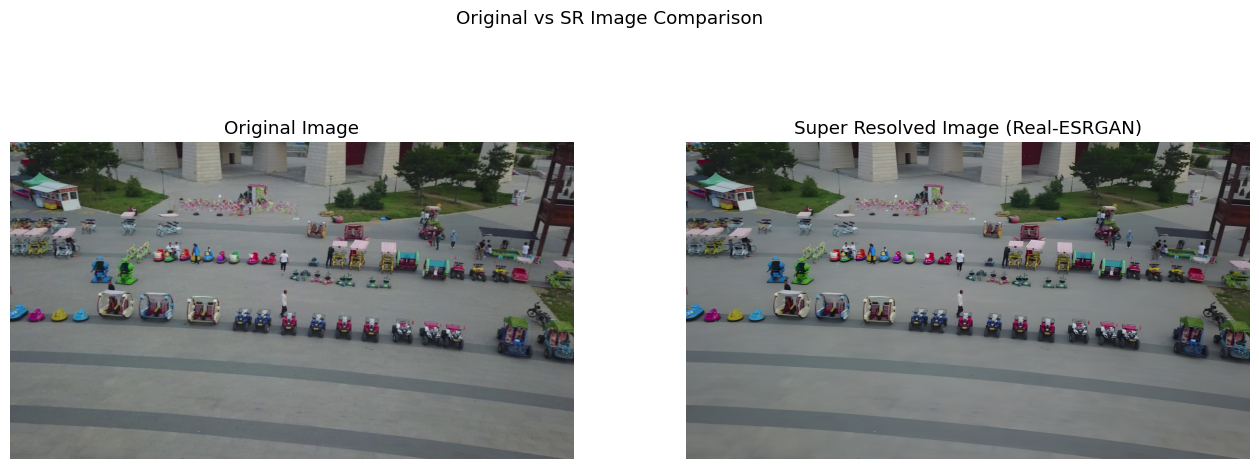

In [19]:
# R-ESRGAN 모델 로드
def load_realesrgan_model():
    model = RealESRGANer(
        scale=4,
        model_path='/home/elicer/Real-ESRGAN/weights/RealESRGAN_x4plus.pth',
        model = RRDBNet(
            num_in_ch=3,
            num_out_ch=3,
            num_feat=64,
            num_block=23,
            num_grow_ch=32,
            scale=4
        ),
        tile=128, tile_pad=10, pre_pad=0, half=False
    )
    return model

# Super Resolution 함수 정의
def apply_super_resolution_realesrgan(image: np.ndarray, sr_model) -> np.ndarray:
    sr_image, _ = sr_model.enhance(image, outscale=4)
    return sr_image

# 입력 이미지 로드

input_img = cv2.imread(img_path)

# R-ESRGAN 적용
sr_model = load_realesrgan_model()
sr_img = apply_super_resolution_realesrgan(input_img, sr_model)

# BGR(OpenCV) → RGB로 변환
input_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
sr_rgb = cv2.cvtColor(sr_img, cv2.COLOR_BGR2RGB)

# 시각화
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.imshow(input_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sr_rgb)
plt.title('Super Resolved Image (Real-ESRGAN)')
plt.axis('off')

plt.suptitle('Original vs SR Image Comparison')
plt.show()

## 색대비 비교

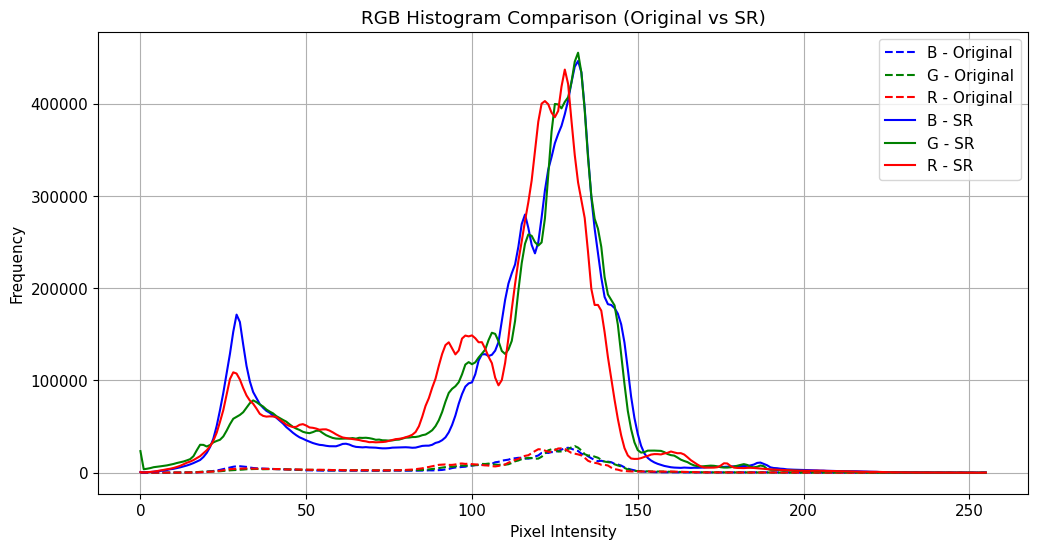

In [20]:
## histogram을 이용하여 색대비를 비교했다. 

colors = ('b', 'g', 'r')
plt.figure(figsize=(12, 6))

# 원본 이미지 히스토그램
for i, color in enumerate(colors):
    hist_orig = cv2.calcHist([input_img], [i], None, [256], [0, 256])
    plt.plot(hist_orig, color=color, linestyle='--', label=f'{color.upper()} - Original')

# SR 이미지 히스토그램
for i, color in enumerate(colors):
    hist_sr = cv2.calcHist([sr_img], [i], None, [256], [0, 256])
    plt.plot(hist_sr, color=color, linestyle='-', label=f'{color.upper()} - SR')

plt.title('RGB Histogram Comparison (Original vs SR)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
## RMS 값을 이용하여 수치적으로 색대비를 비교 (RMS 값이 높으면 색대비가 높음)

def rms_contrast(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.std(gray)

print("Original RMS:", rms_contrast(input_img))
print("SR RMS:", rms_contrast(sr_img))

Original RMS: 32.78507164664151
SR RMS: 35.2374058213063


## 노이즈 비교

In [22]:
## high_frequency energy 기반 노이즈 추정 (값이 낮을 수록 노이즈 적음)

def high_freq_energy(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Sobel 필터로 x, y 방향 경계 검출
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    return np.mean(magnitude)

hf_orig = high_freq_energy(input_img)
hf_sr = high_freq_energy(sr_img)

print(f"Original High-Frequency Energy: {hf_orig:.2f}")
print(f"SR High-Frequency Energy: {hf_sr:.2f}")

Original High-Frequency Energy: 32.60
SR High-Frequency Energy: 19.61


In [23]:
## blur 후 차이값 기반 노이즈 추정 (값이 낮을 수록 노이즈 적음)

def estimate_noise(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    diff = cv2.absdiff(gray, blur)
    return np.mean(diff)

noise_orig = estimate_noise(input_img)
noise_sr = estimate_noise(sr_img)

print(f"Original Estimated Noise: {noise_orig:.2f}")
print(f"SR Estimated Noise: {noise_sr:.2f}")

Original Estimated Noise: 1.62
SR Estimated Noise: 0.96


## 윤곽 비교

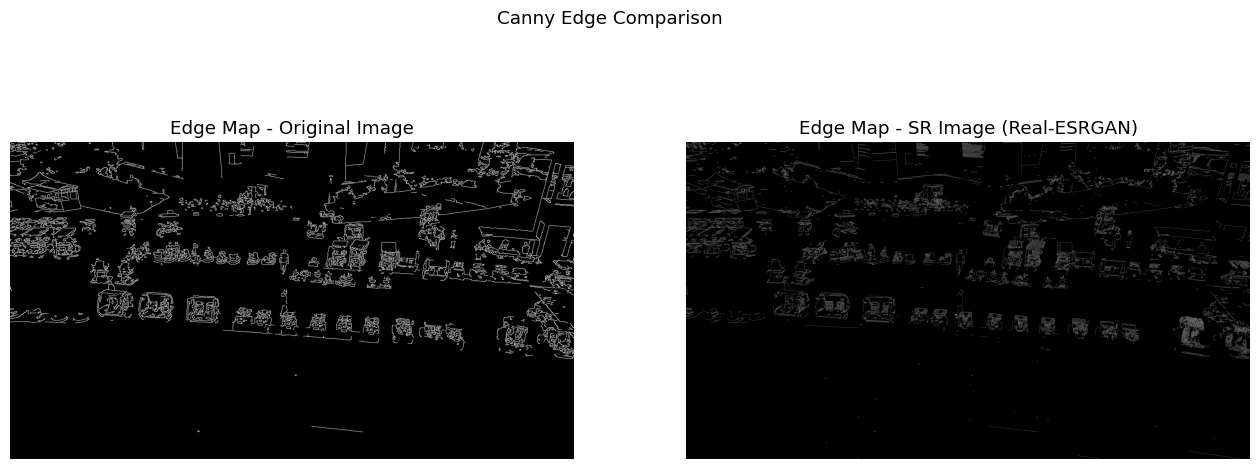

In [24]:
# 흑백 변환
gray_orig = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
gray_sr = cv2.cvtColor(sr_img, cv2.COLOR_BGR2GRAY)

# Canny Edge Detection 적용
edges_orig = cv2.Canny(gray_orig, threshold1=100, threshold2=200)
edges_sr = cv2.Canny(gray_sr, threshold1=100, threshold2=200)

# 결과 시각화
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.imshow(edges_orig, cmap='gray')
plt.title('Edge Map - Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges_sr, cmap='gray')
plt.title('Edge Map - SR Image (Real-ESRGAN)')
plt.axis('off')

plt.suptitle('Canny Edge Comparison')
plt.show()